# 🔎 BioLit Search Assistant — **Full Notebook (with metadata)**

Real-time semantic search across **PubMed-like abstracts** and **MONDO terms** with a rich corpus schema.
Runs on Apple Silicon (CPU) via Sentence-Transformers; includes a **NeMo swap** sketch for NVIDIA GPUs.

### See the repo README to create the environment to run the notebook

In [1]:
import pandas as pd
from sentence_transformers import SentenceTransformer
from sklearn.neighbors import NearestNeighbors
import numpy as np
import matplotlib.pyplot as plt

DATA_PUBMED = "sample_pubmed_abstracts.tsv"
DATA_MONDO  = "sample_mondo_terms.tsv"
MODEL_NAME  = "sentence-transformers/all-MiniLM-L6-v2"
TOP_K = 5

In [2]:
# Load data
pm = pd.read_csv(DATA_PUBMED, sep="\t")   # pmid, title, abstract
on = pd.read_csv(DATA_MONDO,  sep="\t")   # id, label, definition

def fuse_pubmed(r):
    text = f"{r['title']}. {r['abstract']}"
    return {
        "doc_id": r["pmid"],
        "title": r["title"],
        "text": text,
        "source": "pubmed",
        "link": f"https://pubmed.ncbi.nlm.nih.gov/{r['pmid']}/"
    }

def fuse_ontology(r):
    text = f"{r['label']}. {r['definition']}"
    return {
        "doc_id": r["id"],
        "title": r["label"],
        "text": text,
        "source": "mondo",
        "link": f"https://monarchinitiative.org/disease/{r['id'].replace(':','_')}"
    }

corpus = pd.DataFrame(
    [fuse_pubmed(r) for _, r in pm.iterrows()] +
    [fuse_ontology(r) for _, r in on.iterrows()]
)
corpus.head()

,doc_id,title,text,source,link
0,37000001,Dopaminergic neuron degeneration in Parkinson'...,Dopaminergic neuron degeneration in Parkinson'...,pubmed,https://pubmed.ncbi.nlm.nih.gov/37000001/
1,37000002,Beta-amyloid and tau interplay in Alzheimer di...,Beta-amyloid and tau interplay in Alzheimer di...,pubmed,https://pubmed.ncbi.nlm.nih.gov/37000002/
2,37000003,Metabolic control in type 2 diabetes mellitus,Metabolic control in type 2 diabetes mellitus....,pubmed,https://pubmed.ncbi.nlm.nih.gov/37000003/
3,37000004,Biomarkers for myocardial infarction,Biomarkers for myocardial infarction. High-sen...,pubmed,https://pubmed.ncbi.nlm.nih.gov/37000004/
4,37000005,Asthma endotypes and targeted biologics,Asthma endotypes and targeted biologics. Type ...,pubmed,https://pubmed.ncbi.nlm.nih.gov/37000005/


## Embed & Index

In [3]:
model = SentenceTransformer(MODEL_NAME)
vecs = model.encode(corpus["text"].tolist(), normalize_embeddings=True)
vecs = np.array(vecs)
nn = NearestNeighbors(metric="cosine").fit(vecs)

def search(query, k=TOP_K):
    qv = model.encode([query], normalize_embeddings=True)
    distances, indices = nn.kneighbors(qv, n_neighbors=k)
    sims = 1.0 - distances[0]
    rows = []
    for rank, (i, sim) in enumerate(zip(indices[0], sims), start=1):
        rows.append({
            "rank": rank,
            "source": corpus.iloc[i]["source"],
            "id_or_pmid": corpus.iloc[i]["doc_id"],
            "title": corpus.iloc[i]["title"],
            "similarity": float(sim),
            "link": corpus.iloc[i]["link"]
        })
    return pd.DataFrame(rows)

search("dopaminergic neurons in Parkinson's disease")

,rank,source,id_or_pmid,title,similarity,link
0,1,pubmed,37000001,Dopaminergic neuron degeneration in Parkinson'...,0.750815,https://pubmed.ncbi.nlm.nih.gov/37000001/
1,2,mondo,MONDO:0006047,Parkinson disease,0.694166,https://monarchinitiative.org/disease/MONDO_00...
2,3,mondo,MONDO:0013373,Amyotrophic lateral sclerosis,0.385679,https://monarchinitiative.org/disease/MONDO_00...
3,4,mondo,MONDO:0004979,Alzheimer disease,0.330759,https://monarchinitiative.org/disease/MONDO_00...
4,5,pubmed,37000002,Beta-amyloid and tau interplay in Alzheimer di...,0.253504,https://pubmed.ncbi.nlm.nih.gov/37000002/


## (Optional) NeMo Swap (sketch)
```python
# pip install nemo_toolkit  # with CUDA-enabled PyTorch on NVIDIA GPU
# from nemo.collections.nlp.modules.common.text_embedding import SomeNeMoEmbedder  # pseudocode
# nemo_model = SomeNeMoEmbedder.from_pretrained("your-nemo-embedding-model")
# vecs = nemo_model.encode(corpus["text"].tolist())
# vecs = normalize(vecs)  # L2 normalization for cosine
# nn = NearestNeighbors(metric="cosine").fit(vecs)
```

## UMAP Visualization

/Users/whetzel/anaconda3/envs/biolit-nemo/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


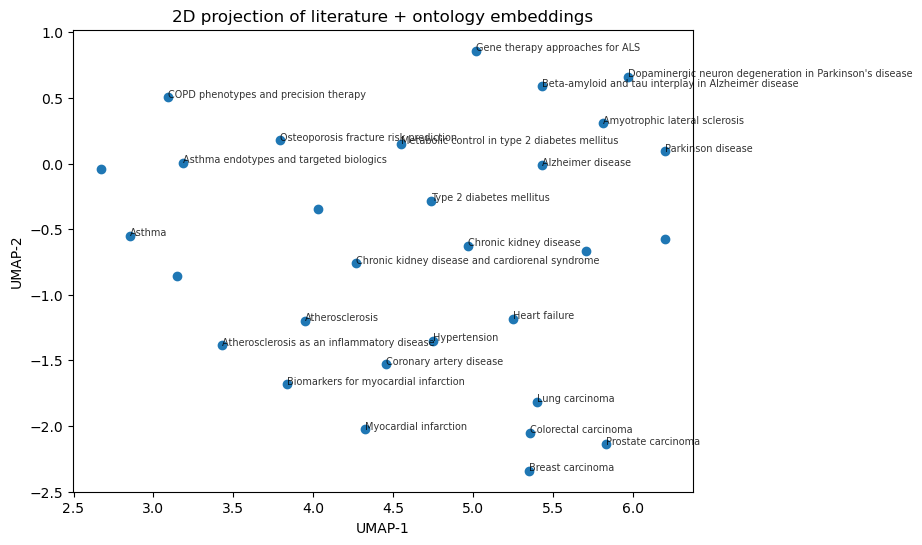

In [4]:
import umap
reducer = umap.UMAP(random_state=42)
emb2d = reducer.fit_transform(vecs)

plt.figure(figsize=(8,6))
plt.scatter(emb2d[:,0], emb2d[:,1])
for i in range(min(len(corpus), 25)):
    plt.annotate(corpus.iloc[i]["title"], (emb2d[i,0], emb2d[i,1]), fontsize=7, alpha=0.8)
plt.title("2D projection of literature + ontology embeddings")
plt.xlabel("UMAP-1"); plt.ylabel("UMAP-2")
plt.show()